[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/work/01_qml_quantum_role_numpy_feature_map.ipynb)


# 1주차: QML에서 Quantum의 역할 실습


이 노트북은 `week1_qml_quantum_role.pdf`의 핵심 흐름을 실습 코드로 재구성한 버전입니다.

**대상**
- QML 파이프라인에서 quantum encoding, feature map, variational circuit, measurement가 각각 어떤 역할을 하는지 정리하려는 학습자
- Qiskit 코드에 들어가기 전에 feature map이 데이터를 어떻게 다른 표현 공간으로 보내는지 확인하려는 학습자

**학습 목표**
- classical data가 quantum encoding을 통해 state vector로 바뀌는 과정을 직접 계산한다.
- feature map이 학습 회로가 아니라 데이터 표현을 바꾸는 단계라는 점을 확인한다.
- quantum kernel이 `|<phi(x_i)|phi(x_j)>|^2` 형태의 유사도 행렬로 해석될 수 있음을 실습한다.
- measurement와 variational circuit이 feature map 뒤에서 어떤 역할을 맡는지 구분한다.


## PDF 확인 요약

확인한 자료: `4.QML에서 Quantum의 역할.pdf` (11 pages, 2026-06-23 생성 PDF)

슬라이드에서 잡은 핵심 흐름은 다음과 같습니다.

1. **QML 구조**: Data -> Quantum Encoding -> Feature Map -> Variational Circuit -> Prediction/Measurement 순서로 설명합니다.
2. **Classical ML vs QML**: QML은 데이터를 양자 상태 또는 양자 특징 공간으로 보내고, 고차원 Hilbert space의 표현을 이용해 패턴을 다룹니다.
3. **Quantum Encoding**: 숫자 데이터 `[0.2, 0.8]` 같은 classical feature를 회전/위상 형태로 회로에 넣어 quantum state로 바꿉니다.
4. **Feature Map**: 학습하는 회로가 아니라, 데이터를 더 분리하기 쉬운 공간으로 보내는 변환입니다.
5. **ZZ Feature Map 예시**: H gate로 상태를 준비하고, P gate가 feature 값을 phase로 넣으며, entanglement가 feature 간 관계를 표현합니다.
6. **Variational Circuit**: trainable parameter `theta`를 갖는 학습부입니다. Feature map과 구분해야 합니다.
7. **Measurement**: quantum state를 classical bit, probability, class score로 읽어 prediction으로 연결합니다.

이 실습은 Qiskit 설치 셀 없이 Colab 기본 패키지인 NumPy/Matplotlib만 사용해 위 역할을 재현합니다.


## Outline

1. Import libraries
2. Create a small XOR-style dataset
3. Build a two-qubit feature map
4. Visualize the encoded quantum states
5. Compute a quantum kernel
6. Use the kernel as a simple classifier
7. Connect the result back to variational circuits and measurement
8. Exercises


## 1. Import libraries

Colab 기본 런타임에 포함된 패키지만 사용합니다. 별도 설치 셀은 두지 않습니다.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(7)
np.set_printoptions(precision=3, suppress=True)


## 2. Create a small classical dataset

PDF에서는 classical data가 quantum encoding과 feature map을 거쳐 다른 표현 공간으로 이동한다고 설명합니다.

여기서는 직선 하나로는 깔끔하게 나누기 어려운 XOR 패턴을 작은 데이터로 만듭니다.


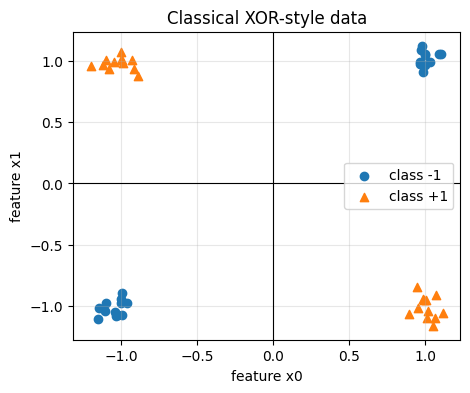

In [2]:
def make_xor_points(noise: float = 0.08) -> tuple[np.ndarray, np.ndarray]:
    centers = np.array([
        [-1.0, -1.0],
        [-1.0, 1.0],
        [1.0, -1.0],
        [1.0, 1.0],
    ])
    labels = np.array([-1, 1, 1, -1])
    repeated_points = np.repeat(centers, repeats=12, axis=0)
    repeated_labels = np.repeat(labels, repeats=12)
    jitter = RNG.normal(loc=0.0, scale=noise, size=repeated_points.shape)
    return repeated_points + jitter, repeated_labels

X, y = make_xor_points()

plt.figure(figsize=(5, 4))
for label, marker, name in [(-1, 'o', 'class -1'), (1, '^', 'class +1')]:
    points = X[y == label]
    plt.scatter(points[:, 0], points[:, 1], marker=marker, label=name)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Classical XOR-style data')
plt.xlabel('feature x0')
plt.ylabel('feature x1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Build a two-qubit feature map

슬라이드의 `zz_feature_map(feature_dimension=2)` 아이디어를 NumPy statevector로 재현합니다.

- H gate: feature를 넣기 전에 두 qubit을 superposition으로 준비합니다.
- Phase gate: 각 feature 값을 phase로 encoding합니다.
- Entangling phase: 두 feature 사이의 관계를 함께 표현합니다.

중요한 점: 이 함수에는 trainable parameter가 없습니다. 즉, **학습 회로가 아니라 feature map**입니다.


In [3]:
SQRT2_INV = 1 / np.sqrt(2)
H_GATE = SQRT2_INV * np.array([[1, 1], [1, -1]], dtype=np.complex128)
ZERO_ZERO = np.array([1, 0, 0, 0], dtype=np.complex128)


def phase_gate(angle: float) -> np.ndarray:
    return np.array([[1, 0], [0, np.exp(1j * angle)]], dtype=np.complex128)


def scale_to_angle(points: np.ndarray) -> np.ndarray:
    minimum = points.min(axis=0)
    maximum = points.max(axis=0)
    span = np.where(maximum - minimum == 0, 1, maximum - minimum)
    return np.pi * (points - minimum) / span


def feature_state(point_angles: np.ndarray, repetitions: int = 2) -> np.ndarray:
    state = ZERO_ZERO.copy()
    for _ in range(repetitions):
        h_layer = np.kron(H_GATE, H_GATE)
        phase_layer = np.kron(phase_gate(point_angles[0]), phase_gate(point_angles[1]))
        relation_angle = (np.pi - point_angles[0]) * (np.pi - point_angles[1])
        entangling_phase = np.diag([1, 1, 1, np.exp(1j * relation_angle)]).astype(np.complex128)
        state = entangling_phase @ phase_layer @ h_layer @ state
    return state / np.linalg.norm(state)

angles = scale_to_angle(X)
encoded_states = np.array([feature_state(point) for point in angles])

print('First classical point:', X[0])
print('Scaled angles:', angles[0])
print('Encoded amplitudes:', encoded_states[0])
print('Probability sum:', np.sum(np.abs(encoded_states[0]) ** 2))


First classical point: [-1.    -0.976]
Scaled angles: [0.273 0.252]
Encoded amplitudes: [0.528+0.273j 0.474-0.021j 0.479-0.02j  0.35 -0.262j]
Probability sum: 0.9999999999999998


## 4. Visualize encoded quantum states

Statevector amplitude는 복소수이므로 바로 그림으로 보기 어렵습니다. 대신 각 computational basis state의 확률을 봅니다.

Measurement는 이 확률 분포에서 classical outcome을 읽는 단계입니다.


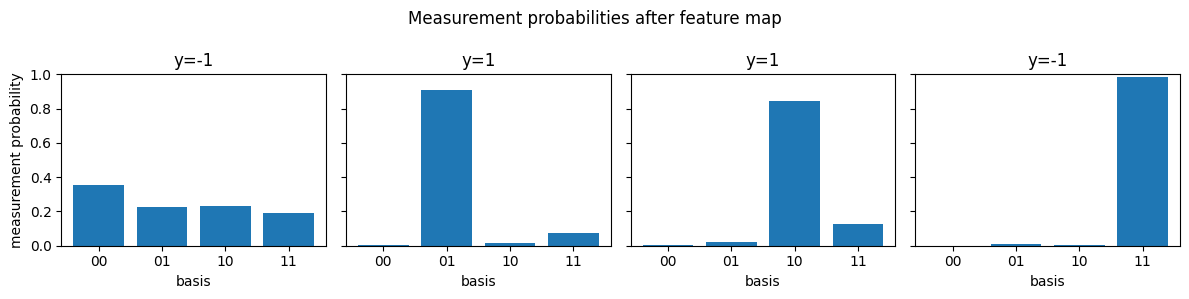

In [4]:
basis_labels = ['00', '01', '10', '11']
example_indices = [0, 12, 24, 36]

fig, axes = plt.subplots(1, len(example_indices), figsize=(12, 3), sharey=True)
for axis, index in zip(axes, example_indices):
    probabilities = np.abs(encoded_states[index]) ** 2
    axis.bar(basis_labels, probabilities)
    axis.set_ylim(0, 1)
    axis.set_title(f'y={y[index]}')
    axis.set_xlabel('basis')
axes[0].set_ylabel('measurement probability')
fig.suptitle('Measurement probabilities after feature map')
plt.tight_layout()
plt.show()


## 5. Compute a quantum kernel

Feature map이 만든 state를 `phi(x)`라고 하면, 두 데이터의 양자 유사도는 다음처럼 볼 수 있습니다.

`K(x_i, x_j) = |<phi(x_i)|phi(x_j)>|^2`

값이 1에 가까울수록 feature map 이후의 quantum state가 비슷하다는 뜻입니다.


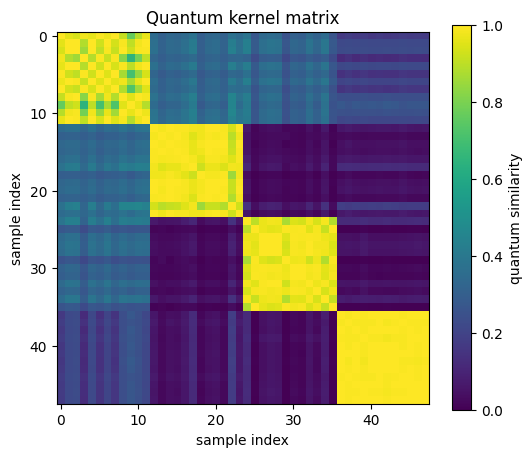

Kernel shape: (48, 48)
Mean same-class similarity: 0.5448183958708225
Mean different-class similarity: 0.1936025810530454


In [5]:
def quantum_kernel(states_a: np.ndarray, states_b: np.ndarray) -> np.ndarray:
    overlaps = states_a @ states_b.conj().T
    return np.abs(overlaps) ** 2

kernel_matrix = quantum_kernel(encoded_states, encoded_states)

plt.figure(figsize=(6, 5))
plt.imshow(kernel_matrix, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='quantum similarity')
plt.title('Quantum kernel matrix')
plt.xlabel('sample index')
plt.ylabel('sample index')
plt.show()

print('Kernel shape:', kernel_matrix.shape)
print('Mean same-class similarity:', kernel_matrix[y[:, None] == y[None, :]].mean())
print('Mean different-class similarity:', kernel_matrix[y[:, None] != y[None, :]].mean())


## 6. Use the kernel as a simple classifier

아래 classifier는 trainable variational circuit이 아닙니다. Feature map이 만든 유사도를 이용해 class score를 계산하는 가장 단순한 예시입니다.

이 단계는 슬라이드의 핵심 구분을 보여줍니다.

- Feature map: 데이터를 quantum feature space로 보냅니다.
- Classifier / variational circuit: 그 표현을 사용해 decision을 만듭니다.
- Measurement: quantum state에서 classical output을 읽습니다.


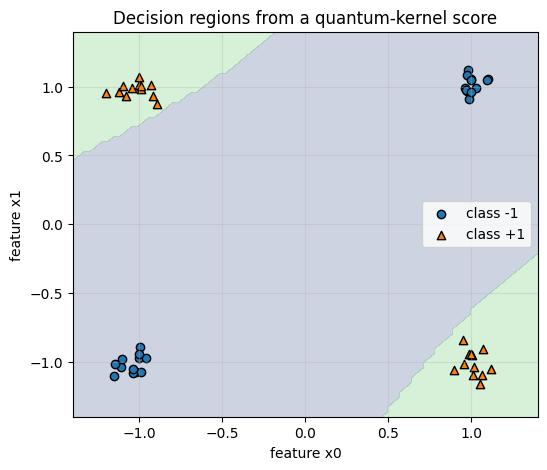

Training accuracy from kernel score: 1.000


In [6]:
def predict_with_kernel(query_points: np.ndarray, train_points: np.ndarray, train_labels: np.ndarray) -> np.ndarray:
    train_angles = scale_to_angle(train_points)
    query_angles = scale_to_angle(np.vstack([train_points, query_points]))[len(train_points):]
    train_states = np.array([feature_state(point) for point in train_angles])
    query_states = np.array([feature_state(point) for point in query_angles])
    similarities = quantum_kernel(query_states, train_states)
    scores = similarities @ train_labels
    return np.where(scores >= 0, 1, -1)

x0_grid, x1_grid = np.meshgrid(np.linspace(-1.4, 1.4, 80), np.linspace(-1.4, 1.4, 80))
grid_points = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
grid_pred = predict_with_kernel(grid_points, X, y).reshape(x0_grid.shape)

plt.figure(figsize=(6, 5))
plt.contourf(x0_grid, x1_grid, grid_pred, levels=[-1.5, 0, 1.5], alpha=0.25)
for label, marker, name in [(-1, 'o', 'class -1'), (1, '^', 'class +1')]:
    points = X[y == label]
    plt.scatter(points[:, 0], points[:, 1], marker=marker, edgecolor='black', label=name)
plt.title('Decision regions from a quantum-kernel score')
plt.xlabel('feature x0')
plt.ylabel('feature x1')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

train_pred = predict_with_kernel(X, X, y)
accuracy = np.mean(train_pred == y)
print(f'Training accuracy from kernel score: {accuracy:.3f}')


## 7. Connect back to the QML pipeline

PDF 기준으로 정리하면 다음처럼 분리할 수 있습니다.

| Stage | 이 실습에서의 대응 | 역할 |
| --- | --- | --- |
| Data | `X`, `y` | classical feature와 label |
| Quantum Encoding | `scale_to_angle` + `phase_gate` | 숫자를 회로 angle/phase로 변환 |
| Feature Map | `feature_state` | 데이터를 quantum feature space로 보냄 |
| Variational Circuit | 이 노트북에서는 생략 | trainable parameter `theta`를 조정하는 학습부 |
| Measurement | `abs(amplitude) ** 2`, kernel score | quantum state를 classical probability/score로 읽음 |

따라서 1주차의 핵심은 **quantum이 모델 전체를 의미하는 것이 아니라, 데이터 표현과 유사도 계산의 공간을 바꾸는 역할을 한다**는 점입니다.


## 8. Exercises

1. `feature_state(point, repetitions=1)`과 `repetitions=3`을 비교해 kernel matrix가 어떻게 달라지는지 확인하세요.
2. `relation_angle` 공식을 `point_angles[0] * point_angles[1]`로 바꾸면 decision region이 어떻게 바뀌는지 비교하세요.
3. 아래 scaffold에서 `repetitions` 값을 바꿔 train accuracy를 기록하세요.


In [7]:
# Exercise scaffold
for repetitions in [1, 2, 3]:
    states = np.array([feature_state(point, repetitions=repetitions) for point in angles])
    kernel = quantum_kernel(states, states)
    same_class = kernel[y[:, None] == y[None, :]].mean()
    different_class = kernel[y[:, None] != y[None, :]].mean()
    print(
        f'repetitions={repetitions}: '
        f'same-class mean={same_class:.3f}, '
        f'different-class mean={different_class:.3f}'
    )


repetitions=1: same-class mean=0.550, different-class mean=0.175
repetitions=2: same-class mean=0.545, different-class mean=0.194
repetitions=3: same-class mean=0.716, different-class mean=0.599


## Common pitfall

Feature map을 trainable model로 착각하면 QML 구조가 헷갈립니다. Feature map은 데이터를 바꾸는 입력 변환이고, variational circuit이나 classifier가 학습을 맡습니다.

다음 단계에서는 이 feature map 뒤에 trainable parameter를 가진 ansatz를 붙이고, measurement 결과로 loss를 계산하는 흐름을 이어가면 됩니다.
